In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
%pip install tqdm
from tqdm import tqdm
import time

In [12]:
data = pd.read_csv('data/dataset_malware.csv').drop(['Name'], axis=1)

le = LabelEncoder()
for column in data: data[column] = le.fit_transform(data[column])

features = data.drop(['Malware'], axis=1)
labels = data['Malware']

train_features,test_features,train_labels,test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=42
 )

model_classes = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier]
models = []
for model in tqdm(model_classes):    
    classifier = model()

    start_time = time.time()
    classifier = classifier.fit(train_features, train_labels)
    train_time = time.time() - start_time

    start_time = time.time()
    predicted_labels = classifier.predict(test_features)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(test_labels, predicted_labels)

    models.append({
        'model_name': model.__name__,
        'model': classifier,
        'predictions': predicted_labels,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time_total': predict_time,
        'predict_time_single_in_milliseconds': predict_time / len(test_features) * 1000,
        'predict_throughtput_per_second': len(test_features) / predict_time,
    })

  0%|          | 0/3 [00:00<?, ?it/s]c:\Users\Lucas\8IAR805---Cybersecurity-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


In [ ]:
target = 'LogisticRegression'  # Change this to the model you want to visualize
final_model = next(item['model'] for item in models if item['model_name'] == target)

%pip install eli5
import eli5
eli5.show_weights(final_model, feature_names=list(train_features.columns.tolist()), top=20)

Weight?,Feature
+0.010,SectionMaxChar
+0.006,SizeOfHeaders
+0.006,e_lfanew
+0.005,BaseOfCode
+0.004,SizeOfInitializedData
+0.004,SizeOfStackReserve
+0.003,e_maxalloc
+0.003,MinorLinkerVersion
+0.003,SizeOfHeapReserve
+0.002,SuspiciousImportFunctions


In [13]:
target = 'RandomForestClassifier'  # Change this to the model you want to visualize
final_model = next(item['model'] for item in models if item['model_name'] == target)

final_model.feature_importances_

array([0.00000000e+00, 1.07305579e-03, 3.52814390e-03, 1.52045329e-05,
       6.44178769e-04, 4.73023012e-04, 2.09739386e-03, 1.59854541e-05,
       2.18522430e-03, 0.00000000e+00, 1.45902848e-04, 2.34977642e-05,
       4.56571637e-05, 2.07631130e-03, 2.81781603e-04, 1.43708728e-04,
       6.42377488e-03, 2.33715999e-03, 4.27269239e-03, 5.66403664e-02,
       1.41720373e-04, 2.27928040e-04, 1.56758095e-03, 3.90429790e-02,
       2.07553269e-03, 8.28405183e-02, 2.18950052e-03, 4.22975978e-03,
       2.47939327e-02, 5.84389132e-04, 8.66413656e-03, 1.57653158e-03,
       3.59241100e-02, 8.81496344e-03, 1.54695392e-03, 6.14766538e-02,
       1.06503739e-01, 2.01603679e-02, 3.76018062e-02, 7.37864520e-02,
       6.69673607e-02, 1.36229491e-02, 1.15898828e-02, 9.00944676e-03,
       6.41796324e-02, 2.57624315e-02, 6.03139129e-02, 1.29853317e-03,
       4.35769948e-03, 1.73068194e-03, 1.61539571e-04, 1.73652790e-05,
       4.01257367e-03, 3.74058264e-05, 4.62904337e-03, 1.09255012e-02,
      

### On remarque que certaine colone n'impactent pas le résultat donc on pourrait les enlever

<Axes: title={'center': 'Feature Importance'}>

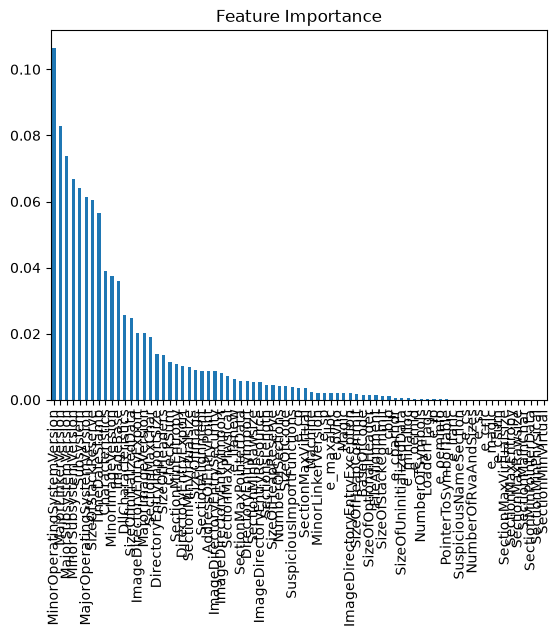

In [14]:
import pandas as pd

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=train_features.columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar', title='Feature Importance')

In [15]:
importance_table = (
    feature_importance
    .rename('importance')
    .reset_index()
    .rename(columns={'index': 'champ'})
)

display(importance_table)

,champ,importance
0,MinorOperatingSystemVersion,0.106504
1,MajorLinkerVersion,0.082841
2,MajorSubsystemVersion,0.073786
3,MinorSubsystemVersion,0.066967
4,Subsystem,0.064180
...,...,...
72,SectionMaxRawsize,0.000000
73,SectionMainChar,0.000000
74,SectionMinPointerData,0.000000
75,SectionMinPhysical,0.000000


In [31]:
non_important_columns = feature_importance[feature_importance < 0.02].index.tolist()
reduced_features = features.drop(columns=non_important_columns)

reduced_train_features, reduced_test_features, reduced_train_labels, reduced_test_labels = train_test_split(
    reduced_features, labels, test_size=0.2, random_state=42
 )

reduced_models = []
for model in tqdm(model_classes):
    classifier = model()

    start_time = time.time()
    classifier.fit(reduced_train_features, reduced_train_labels)
    train_time = time.time() - start_time

    start_time = time.time()
    predicted_labels = classifier.predict(reduced_test_features)
    predict_time = time.time() - start_time

    reduced_models.append({
        'model_name': model.__name__,
        'model': classifier,
        'accuracy': accuracy_score(reduced_test_labels, predicted_labels),
        'train_time': train_time,
        'predict_time_total': predict_time,
        'predict_time_single_in_milliseconds': predict_time / len(reduced_test_features) * 1000,
    })

comparison = []
for result in models:
    comparison.append({
        'version': 'Toutes les colonnes',
        'model_name': result['model_name'],
        'accuracy': result['accuracy'],
        'train_time': result['train_time'],
        'predict_time_total': result['predict_time_total'],
        'predict_time_single_in_milliseconds': result['predict_time_single_in_milliseconds'],
        'number_of_columns': features.shape[1],
    })

for result in reduced_models:
    comparison.append({
        'version': 'Colonnes importantes uniquement',
        'model_name': result['model_name'],
        'accuracy': result['accuracy'],
        'train_time': result['train_time'],
        'predict_time_total': result['predict_time_total'],
        'predict_time_single_in_milliseconds': result['predict_time_single_in_milliseconds'],
        'number_of_columns': reduced_features.shape[1],
    })

comparison_table = pd.DataFrame(comparison)
display(comparison_table)

print(f"Colonnes supprimées : {non_important_columns}")
print(f"Nombre de colonnes restantes : {reduced_features.shape[1]}")

  0%|          | 0/3 [00:00<?, ?it/s]c:\Users\Lucas\8IAR805---Cybersecurity-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 3/3 [00:01<00:00,  1.84it/s]


,version,model_name,accuracy,train_time,predict_time_total,predict_time_single_in_milliseconds,number_of_columns
0,Toutes les colonnes,LogisticRegression,0.884527,0.383958,0.004717,0.001202,77
1,Toutes les colonnes,DecisionTreeClassifier,0.986490,0.503341,0.004701,0.001198,77
2,Toutes les colonnes,RandomForestClassifier,0.992098,3.054084,0.155248,0.039574,77
3,Colonnes importantes uniquement,LogisticRegression,0.945705,0.149372,0.002060,0.000525,15
4,Colonnes importantes uniquement,DecisionTreeClassifier,0.989039,0.084850,0.002323,0.000592,15
5,Colonnes importantes uniquement,RandomForestClassifier,0.993372,1.326121,0.061476,0.015671,15


Colonnes supprimées : ['SectionMaxChar', 'DirectoryEntryImportSize', 'SizeOfHeaders', 'CheckSum', 'SectionMinEntropy', 'DirectoryEntryExport', 'SectionMinVirtualsize', 'SizeOfImage', 'SectionAlignment', 'AddressOfEntryPoint', 'ImageDirectoryEntrySecurity', 'ImageDirectoryEntryImport', 'SectionMaxPhysical', 'e_lfanew', 'SectionMaxPointerData', 'DirectoryEntryImport', 'SectionMinRawsize', 'ImageDirectoryEntryResource', 'SectionsLength', 'SizeOfHeapReserve', 'NumberOfSections', 'SizeOfCode', 'SuspiciousImportFunctions', 'e_cp', 'SectionMaxVirtual', 'Machine', 'MinorLinkerVersion', 'e_sp', 'e_maxalloc', 'e_ovno', 'Magic', 'ImageDirectoryEntryException', 'SizeOfHeapCommit', 'BaseOfCode', 'SizeOfOptionalHeader', 'FileAlignment', 'SizeOfStackCommit', 'e_cblp', 'e_cparhdr', 'SizeOfUninitializedData', 'e_minalloc', 'e_oemid', 'NumberOfSymbols', 'LoaderFlags', 'e_ip', 'e_oeminfo', 'PointerToSymbolTable', 'e_lfarlc', 'SuspiciousNameSection', 'e_cs', 'NumberOfRvaAndSizes', 'e_ss', 'e_crlc', 'e_mag

# À faire : 
1. Répondez à cette question : Que se passerais-t-il si on enlève les colonnes à importance nulle? Comparez le avant et après sur performance, temps d'entrainement, temps de prédiction, et besoin en colonnes. 

2. Si oui, jusqu'où peut-on aller? Combien peux-t-on enlever de colonnes (ainsi que lesquelles et pourquoi) et garantir de rester à 99% ?